# RaksaDana — Cross-Ticker Evaluation Comparison
Notebook ini load hasil evaluasi dari ketiga model (BBCA, BBRI, BMRI) dan membandingkannya secara side-by-side.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
%matplotlib inline

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name.lower() == 'notebook' else cwd
REPORT_DIR  = ROOT / 'reports' / 'return_model'
FIGURE_DIR  = ROOT / 'outputs' / 'figures'
EVAL_DIR    = ROOT / 'reports' / 'evaluation'
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TICKERS      = ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']
SAFE_TICKERS = [t.replace('.', '_') for t in TICKERS]

ACTUAL_COLOR = '#1565C0'
COLORS       = ['#D32F2F', '#2E7D32', '#F57C00']
TICKER_COLOR = dict(zip(TICKERS, COLORS))

print('ROOT       :', ROOT)
print('REPORT_DIR :', REPORT_DIR)
print('Tickers    :', TICKERS)

ROOT       : c:\Users\akbar\VSCode Project\RaksaDana
REPORT_DIR : c:\Users\akbar\VSCode Project\RaksaDana\reports\return_model
Tickers    : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']


## Load Reports

In [2]:
def load_report(safe_ticker, filename):
    path = REPORT_DIR / safe_ticker / f'return_{safe_ticker}_{filename}.csv'
    return pd.read_csv(path)

metrics_all    = pd.concat([load_report(t, 'metrics')    for t in SAFE_TICKERS], ignore_index=True)
fit_status_all = pd.concat([load_report(t, 'fit_status') for t in SAFE_TICKERS], ignore_index=True)
acceptance_all = pd.concat([load_report(t, 'acceptance') for t in SAFE_TICKERS], ignore_index=True)
signal_all     = pd.concat([load_report(t, 'one_step_signal') for t in SAFE_TICKERS], ignore_index=True)
forecast_all   = {t: load_report(s, 'forecast_30d') for t, s in zip(TICKERS, SAFE_TICKERS)}

print('metrics_all shape    :', metrics_all.shape)
print('Models found         :', metrics_all['Model'].unique().tolist())
print('Tickers found        :', metrics_all['Ticker'].unique().tolist())

metrics_all shape    : (24, 10)
Models found         : ['Naive_Zero_Return', 'MA5_Return', 'Ridge_Return', 'LSTM_Return_Ensemble']
Tickers found        : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']


## LSTM Test Metrics — All Tickers

In [3]:
METRIC_FORMAT = {
    'Return_MAE':         '{:.5f}',
    'Return_RMSE':        '{:.5f}',
    'Price_MAE':          '{:,.2f}',
    'Price_RMSE':         '{:,.2f}',
    'Price_MAPE':         '{:.3f}%',
    'Price_R2':           '{:.4f}',
    'Direction_Accuracy': '{:.2f}%',
}

lstm_test = (
    metrics_all[
        (metrics_all['Model'] == 'LSTM_Return_Ensemble') &
        (metrics_all['Split'] == 'Test')
    ]
    .set_index('Ticker')
    [['Return_MAE', 'Return_RMSE', 'Price_MAE', 'Price_RMSE', 'Price_MAPE', 'Price_R2', 'Direction_Accuracy']]
)

print('=' * 80)
print('LSTM TEST METRICS — ALL TICKERS')
print('=' * 80)
display(
    lstm_test.style
    .format(METRIC_FORMAT)
    .background_gradient(subset=['Return_RMSE', 'Price_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
)

LSTM TEST METRICS — ALL TICKERS


,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
Ticker,,,,,,,
BBCA.JK,0.01182,0.01592,100.51,133.87,1.181%,0.9615,48.71%
BBRI.JK,0.01531,0.02076,57.70,77.07,1.530%,0.9747,44.66%
BMRI.JK,0.01520,0.02108,72.31,98.97,1.521%,0.9747,46.14%


## Train vs Test — LSTM Only

In [4]:
lstm_all_splits = (
    metrics_all[metrics_all['Model'] == 'LSTM_Return_Ensemble']
    .set_index(['Ticker', 'Split'])
    [['Return_MAE', 'Return_RMSE', 'Price_MAE', 'Price_RMSE', 'Price_MAPE', 'Price_R2', 'Direction_Accuracy']]
    .sort_index()
)

print('=' * 80)
print('LSTM TRAIN vs TEST — ALL TICKERS')
print('=' * 80)
display(
    lstm_all_splits.style
    .format(METRIC_FORMAT)
    .background_gradient(subset=['Return_RMSE', 'Price_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
)

LSTM TRAIN vs TEST — ALL TICKERS


## Model Comparison — LSTM vs Baselines (Test)

In [5]:
test_compare = (
    metrics_all[metrics_all['Split'] == 'Test']
    .set_index(['Ticker', 'Model'])
    [['Return_RMSE', 'Price_MAPE', 'Price_R2', 'Direction_Accuracy']]
    .sort_index()
)

print('=' * 80)
print('ALL MODELS TEST COMPARISON')
print('=' * 80)
display(
    test_compare.style
    .format({
        'Return_RMSE':        '{:.5f}',
        'Price_MAPE':         '{:.3f}%',
        'Price_R2':           '{:.4f}',
        'Direction_Accuracy': '{:.2f}%',
    })
    .background_gradient(subset=['Return_RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
)

ALL MODELS TEST COMPARISON


## Fit Status — Overfit / Good Fit Check

In [6]:
lstm_fit = fit_status_all[fit_status_all['Model'] == 'LSTM_Return_Ensemble'].set_index('Ticker')

print('=' * 80)
print('FIT STATUS — LSTM')
print('=' * 80)
display(
    lstm_fit[['Train_Return_RMSE', 'Test_Return_RMSE', 'Return_Gap_Test/Train',
              'Train_Price_RMSE',  'Test_Price_RMSE',  'Price_Gap_Test/Train',
              'Fit_Status', 'Reason']]
    .style
    .format({
        'Train_Return_RMSE':   '{:.5f}',
        'Test_Return_RMSE':    '{:.5f}',
        'Return_Gap_Test/Train': '{:.2f}x',
        'Train_Price_RMSE':    '{:,.2f}',
        'Test_Price_RMSE':     '{:,.2f}',
        'Price_Gap_Test/Train': '{:.2f}x',
    })
)

FIT STATUS — LSTM


,Train_Return_RMSE,Test_Return_RMSE,Return_Gap_Test/Train,Train_Price_RMSE,Test_Price_RMSE,Price_Gap_Test/Train,Fit_Status,Reason
Ticker,,,,,,,,
BBCA.JK,0.01435,0.01592,1.11x,70.68,133.87,1.89x,Mild overfit,"Test error lebih tinggi, tapi gap belum ekstrem."
BBRI.JK,0.01971,0.02076,1.05x,43.96,77.07,1.75x,Mild overfit,"Test error lebih tinggi, tapi gap belum ekstrem."
BMRI.JK,0.01969,0.02108,1.07x,44.13,98.97,2.24x,Mild overfit,"Test error lebih tinggi, tapi gap belum ekstrem."


## Acceptance Check — Beats Naive Baseline?

In [7]:
lstm_accept = (
    acceptance_all[acceptance_all['Model'] == 'LSTM_Return_Ensemble']
    .set_index('Ticker')
    [['Beats_Naive_Return_RMSE', 'Beats_Naive_Price_RMSE', 'Beats_Naive_DA',
      'Naive_Return_RMSE', 'Model_Return_RMSE', 'Naive_DA', 'Model_DA']]
)

print('=' * 80)
print('ACCEPTANCE CHECK VS NAIVE BASELINE — LSTM')
print('=' * 80)
display(
    lstm_accept.style
    .format({
        'Naive_Return_RMSE': '{:.5f}',
        'Model_Return_RMSE': '{:.5f}',
        'Naive_DA':          '{:.2f}%',
        'Model_DA':          '{:.2f}%',
    })
)

ACCEPTANCE CHECK VS NAIVE BASELINE — LSTM


,Beats_Naive_Return_RMSE,Beats_Naive_Price_RMSE,Beats_Naive_DA,Naive_Return_RMSE,Model_Return_RMSE,Naive_DA,Model_DA
Ticker,,,,,,,
BBCA.JK,False,True,True,0.01590,0.01592,8.71%,48.71%
BBRI.JK,False,False,True,0.02042,0.02076,6.32%,44.66%
BMRI.JK,False,False,True,0.02089,0.02108,10.50%,46.14%


## One-Step Signal — Latest Prediction

In [8]:
print('=' * 80)
print('LATEST ONE-STEP SIGNAL (last test date per ticker)')
print('=' * 80)
display(
    signal_all.set_index('Ticker')
    .style
    .format({
        'Base_Close':                  '{:,.2f}',
        'Predicted_Next_Log_Return':   '{:.5f}',
        'Predicted_Next_Close':        '{:,.2f}',
    })
)

LATEST ONE-STEP SIGNAL (last test date per ticker)


,Signal_Date,Base_Close,Predicted_Next_Log_Return,Predicted_Next_Close,Note
Ticker,,,,,
BBCA.JK,2026-01-19,"7,736.33",0.00106,"7,744.54",One-step signal only; recursive 30-day forecast intentionally disabled.
BBRI.JK,2026-01-19,"3,587.91",0.00008,"3,588.20",One-step signal only; recursive 30-day forecast intentionally disabled.
BMRI.JK,2026-01-19,"4,583.73",0.00339,"4,599.28",One-step signal only; recursive 30-day forecast intentionally disabled.


## MAPE Comparison Chart

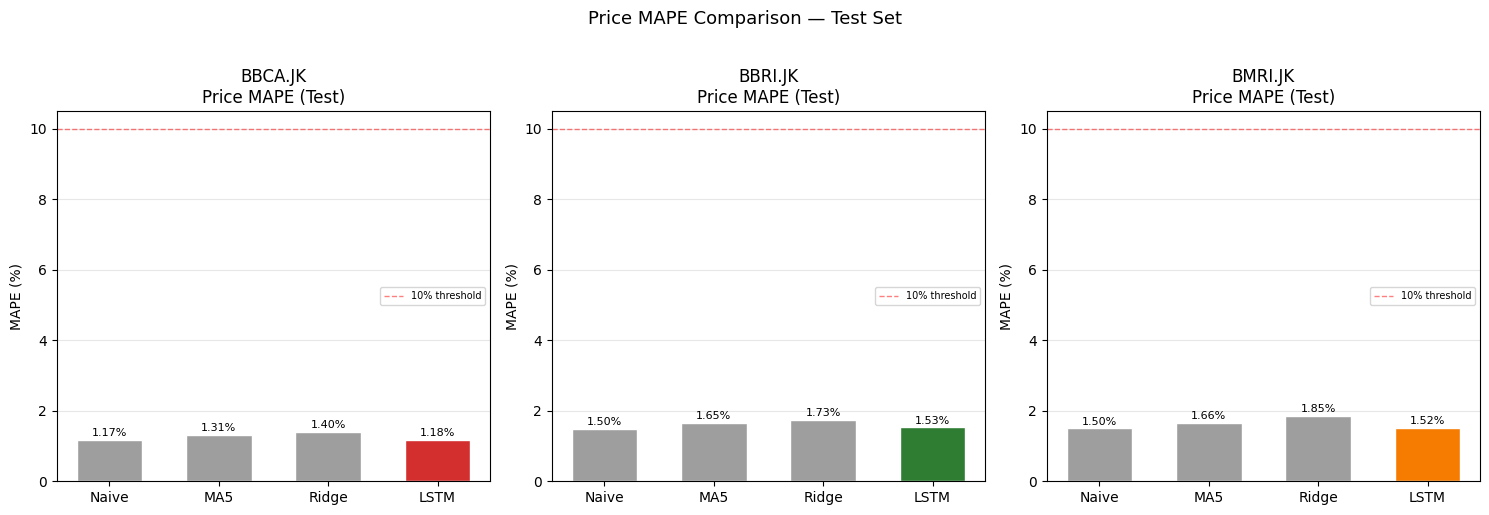

In [9]:
models_to_plot = ['Naive_Zero_Return', 'MA5_Return', 'Ridge_Return', 'LSTM_Return_Ensemble']
model_labels   = ['Naive', 'MA5', 'Ridge', 'LSTM']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    ticker_test = metrics_all[
        (metrics_all['Ticker'] == ticker) & (metrics_all['Split'] == 'Test')
    ].set_index('Model')

    mape_vals = [ticker_test.loc[m, 'Price_MAPE'] if m in ticker_test.index else np.nan for m in models_to_plot]
    bar_colors = ['#9E9E9E', '#9E9E9E', '#9E9E9E', TICKER_COLOR[ticker]]
    bars = ax.bar(model_labels, mape_vals, color=bar_colors, edgecolor='white', width=0.6)

    for bar, val in zip(bars, mape_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

    ax.axhline(10, color='red', lw=1, linestyle='--', alpha=0.5, label='10% threshold')
    ax.set_title(f'{ticker}\nPrice MAPE (Test)')
    ax.set_ylabel('MAPE (%)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('Price MAPE Comparison — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'mape_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## Price R² Comparison Chart

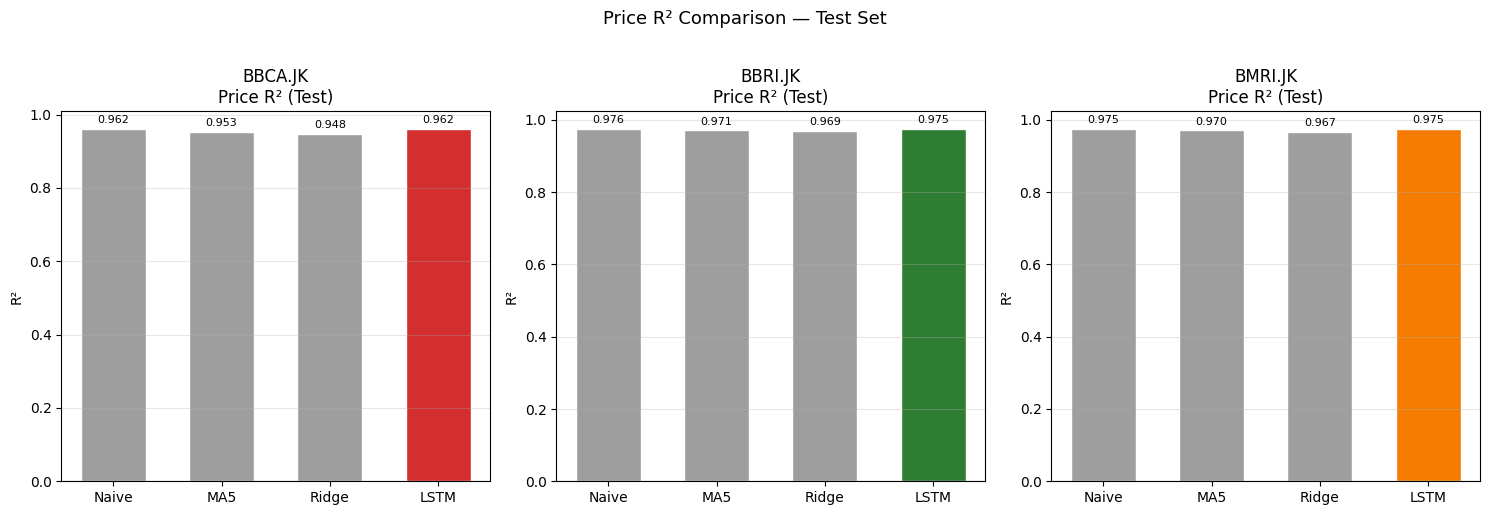

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    ticker_test = metrics_all[
        (metrics_all['Ticker'] == ticker) & (metrics_all['Split'] == 'Test')
    ].set_index('Model')

    r2_vals    = [ticker_test.loc[m, 'Price_R2'] if m in ticker_test.index else np.nan for m in models_to_plot]
    bar_colors = ['#9E9E9E', '#9E9E9E', '#9E9E9E', TICKER_COLOR[ticker]]
    bars = ax.bar(model_labels, r2_vals, color=bar_colors, edgecolor='white', width=0.6)

    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.01 if val >= 0 else -0.06),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0, color='black', lw=0.8, linestyle='-', alpha=0.4)
    ax.set_title(f'{ticker}\nPrice R² (Test)')
    ax.set_ylabel('R²')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Price R² Comparison — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'r2_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## Directional Accuracy Comparison Chart

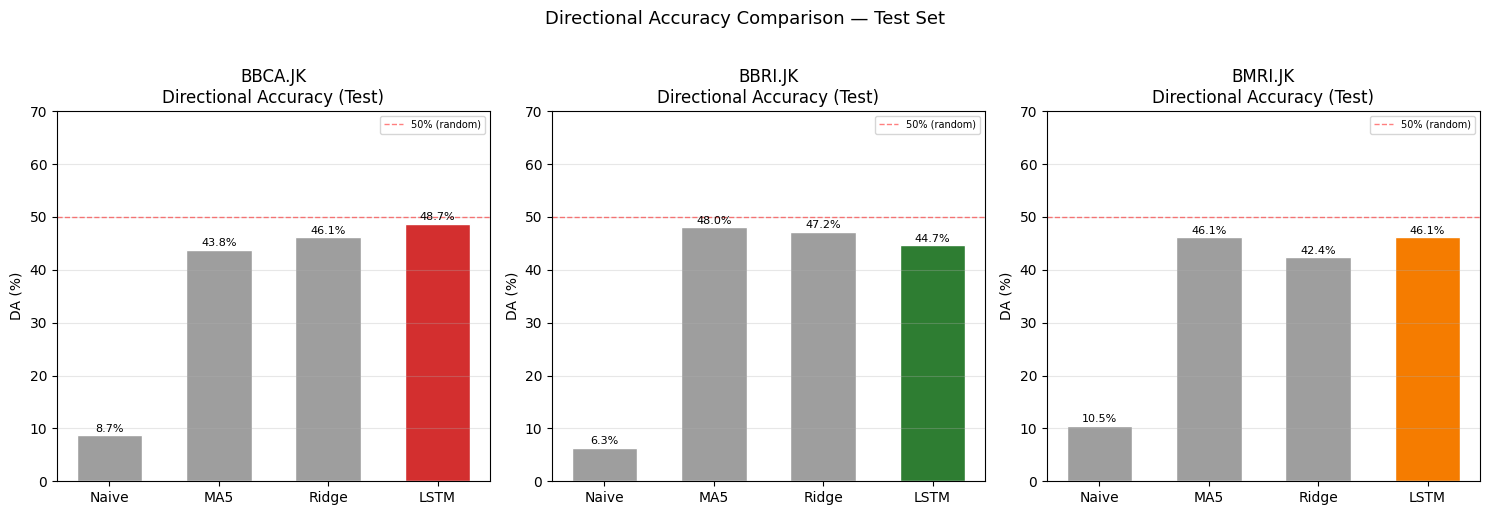

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    ticker_test = metrics_all[
        (metrics_all['Ticker'] == ticker) & (metrics_all['Split'] == 'Test')
    ].set_index('Model')

    da_vals    = [ticker_test.loc[m, 'Direction_Accuracy'] if m in ticker_test.index else np.nan for m in models_to_plot]
    bar_colors = ['#9E9E9E', '#9E9E9E', '#9E9E9E', TICKER_COLOR[ticker]]
    bars = ax.bar(model_labels, da_vals, color=bar_colors, edgecolor='white', width=0.6)

    for bar, val in zip(bars, da_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    ax.axhline(50, color='red', lw=1, linestyle='--', alpha=0.5, label='50% (random)')
    ax.set_title(f'{ticker}\nDirectional Accuracy (Test)')
    ax.set_ylabel('DA (%)')
    ax.set_ylim(0, 70)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('Directional Accuracy Comparison — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'da_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 30-Day Forecast — All Tickers

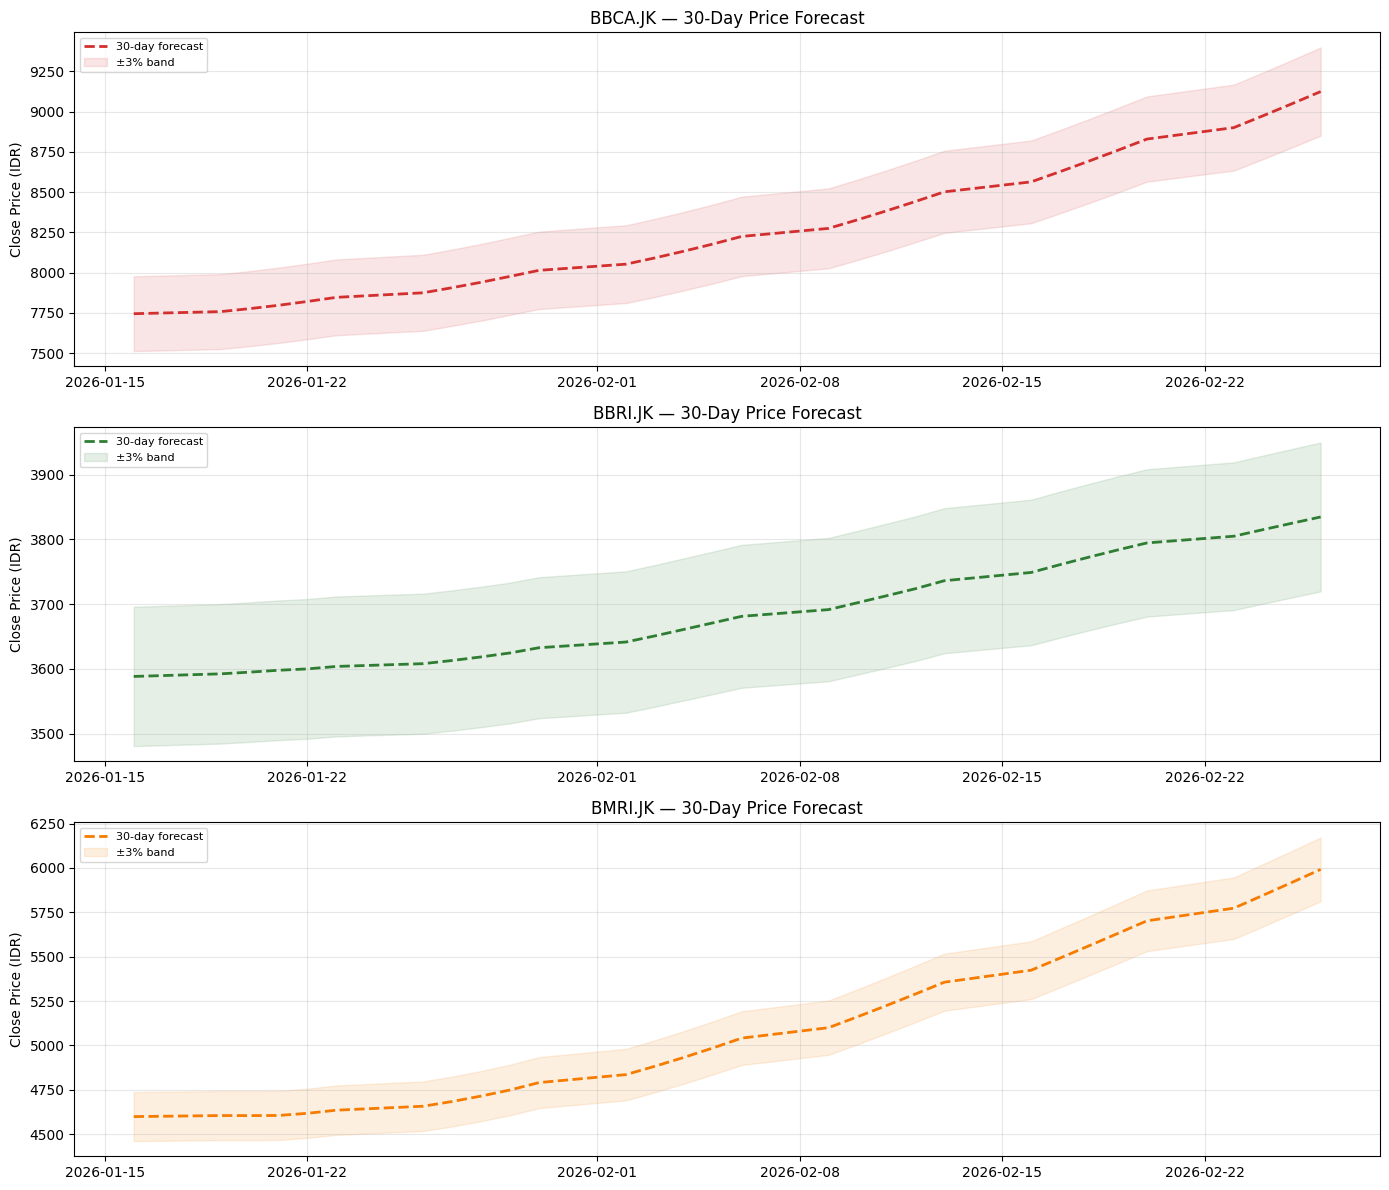

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, ticker, safe in zip(axes, TICKERS, SAFE_TICKERS):
    fc = forecast_all[ticker].copy()
    fc['Date'] = pd.to_datetime(fc['Date'])

    ax.plot(fc['Date'], fc['Predicted_Close'],
            color=TICKER_COLOR[ticker], lw=2, linestyle='--', label='30-day forecast')
    ax.fill_between(fc['Date'],
                    fc['Predicted_Close'] * 0.97,
                    fc['Predicted_Close'] * 1.03,
                    color=TICKER_COLOR[ticker], alpha=0.12, label='±3% band')
    ax.set_title(f'{ticker} — 30-Day Price Forecast')
    ax.set_ylabel('Close Price (IDR)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'forecast_30d_all.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary

In [13]:
summary = lstm_test[['Price_MAPE', 'Price_R2', 'Direction_Accuracy']].copy()
summary['MAPE_Category'] = summary['Price_MAPE'].apply(
    lambda x: 'Sangat Baik (<=10%)' if x <= 10 else ('Baik (10-20%)' if x <= 20 else 'Cukup (>20%)')
)
summary['Fit_Status'] = lstm_fit['Fit_Status']
summary['Beats_Naive_DA'] = lstm_accept['Beats_Naive_DA']

print('=' * 80)
print('RINGKASAN EVALUASI KETIGA MODEL LSTM')
print('=' * 80)
display(
    summary.style
    .format({
        'Price_MAPE':         '{:.3f}%',
        'Price_R2':           '{:.4f}',
        'Direction_Accuracy': '{:.2f}%',
    })
    .background_gradient(subset=['Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
)

summary.to_csv(EVAL_DIR / 'evaluation_summary.csv')
print('\nSaved:', EVAL_DIR / 'evaluation_summary.csv')

RINGKASAN EVALUASI KETIGA MODEL LSTM


,Price_MAPE,Price_R2,Direction_Accuracy,MAPE_Category,Fit_Status,Beats_Naive_DA
Ticker,,,,,,
BBCA.JK,1.181%,0.9615,48.71%,Sangat Baik (<=10%),Mild overfit,True
BBRI.JK,1.530%,0.9747,44.66%,Sangat Baik (<=10%),Mild overfit,True
BMRI.JK,1.521%,0.9747,46.14%,Sangat Baik (<=10%),Mild overfit,True



Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\evaluation\evaluation_summary.csv
